In [53]:
from flax import linen as nn
import jax.numpy as jnp
import jax
import math

In [54]:
class PINN(nn.Module):
    features: list 
    # An example of above list is [1,64,64,1]
    def setup(self):
        self.layers = [nn.Dense(f) for f in self.features]
        # In the above we define the layers
        
    def __call__(self,x):
        # Define the forward pass
        for i, lyr in enumerate(self.layers):
            x = lyr(x)
            if i<len(self.layers)-1:
                x = nn.tanh(x)
                # This is the application of activation function
                # except at the last layer.
        return x
        

In [55]:
model = PINN(features = [64,64,1])

In [56]:
key = jax.random.PRNGKey(0)
dummy_input = jnp.ones((1,1))
params = model.init(key, dummy_input)['params']

In [57]:
# This is called a wrapper. It is the evaluation of model at some input
def u_pred(params, x):
    # To do this we first put x and t into the same array
    input_vec = jnp.array([x])
    # Now we see how the model actually combines the parameters
    # and the input to given an ouput
    # Basically run theforward pass
    return model.apply({'params': params}, input_vec)[0]
print(u_pred(params,1))

0.30590987


In [58]:
# u_pred1 = u_pred(params,1)
du_dx = jax.grad(u_pred, argnums = 1)
# The above means that the u_pred is being differentiated with respect ot x
# print(du_dx.apply({'params':params},1)[0])
print(du_dx(params,1.0))
d2u_dx2 = jax.grad(du_dx, argnums = 1)

# here we have created the second derivative
print(d2u_dx2)

0.06815474
<function u_pred at 0x79027df025f0>


**Now we define the PDE which we are trying to solve**

In [59]:
def residual(params, x):
    return d2u_dx2(params,x) + 2

In [60]:
# We have to vectorise the residual so that it can handle
# entire batch of data at once
v_pde_residual = jax.vmap(residual, in_axes=(None,0))

# Now comes the main definition of the pde_residual
def physics_loss(params, x_batch):
    loss = v_pde_residual(params, x_batch)
    return jnp.mean(jnp.square(loss))

In [61]:
import optax

# FIrst we define the optimizer which is the usual Adam
# This is done through the module optax

from flax.training import train_state
optimizer = optax.adam(learning_rate=1e-3)

# We create the initial state of the model
state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=params,
    tx=optimizer)

In [62]:
# We need to add some boundary values
x_boundary = 0.0
u_boundary = 1.0
du_dx_boundary = 1.0

# ALso we vectorise the du_dx 
v_du_dx = jax.vmap(du_dx, in_axes = (None,0))

In [63]:
# I still have to understand the use of the command below
@jax.jit
def train_step(state, x_batch, x_boundary, u_boundary, du_dx_boundary):
    def loss_fn(params):
        
        # This is the pde loss
        pde_loss = physics_loss(params, x_batch)

        # Then we add the Dirichlet boundary condition
        # u_boundary_pred = state.apply_fn({'params' : params}, jnp.stack([x_boundary], axis=-1))
        u_boundary_pred = u_pred(params, x_boundary)
        boundary_dr_loss= jnp.mean(jnp.square(u_boundary_pred-u_boundary))

        # now we add the neumann boundary condition at the same boundary point
        du_dx_pred = du_dx(params, x_boundary)
    
        loss_neumann = jnp.mean(jnp.square(du_dx_pred - du_dx_boundary))
        return pde_loss + boundary_dr_loss + loss_neumann
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

In [64]:
# These are the point where we want to evaluate the trained network on.
# These are usually higher than the collocation points which demonstrates
# the advanatage of PINNs.

x_batch = jnp.linspace(0,10,100)

In [65]:
loss_track=[]
epochs = 200000
# train_step_track=[]
for step in range(epochs):
    state, loss_val = train_step(state, x_batch, x_boundary, u_boundary, du_dx_boundary)
    loss_track.append([loss_val,step])
    if step % 10000 == 0:
        print(f"Step {step}, Loss: {loss_val:.4e}")

Step 0, Loss: 5.0121e+00
Step 10000, Loss: 7.1615e-04
Step 20000, Loss: 1.8672e-04
Step 30000, Loss: 4.9330e-02
Step 40000, Loss: 8.2879e-03
Step 50000, Loss: 1.8604e-03
Step 60000, Loss: 1.5798e-02
Step 70000, Loss: 5.7849e-05
Step 80000, Loss: 2.7705e-03
Step 90000, Loss: 2.0059e-05
Step 100000, Loss: 1.5131e-03
Step 110000, Loss: 4.2507e-05
Step 120000, Loss: 1.9093e-05
Step 130000, Loss: 5.7681e-06
Step 140000, Loss: 2.1677e-03
Step 150000, Loss: 5.6149e-05
Step 160000, Loss: 8.2499e-05
Step 170000, Loss: 3.9670e-05
Step 180000, Loss: 1.2204e-05
Step 190000, Loss: 6.9284e-05


In [66]:
import numpy as np
x_check = np.linspace(0,10,1000)
v_u_pred = jax.vmap(u_pred, in_axes=(None,0))
y_check = v_u_pred(state.params,x_check)

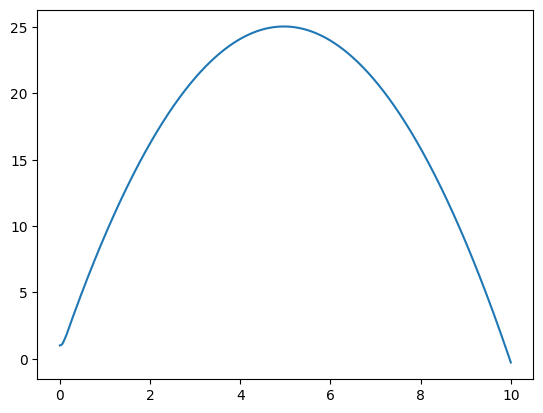

In [67]:
import matplotlib.pyplot as plt
plt.plot(x_check,y_check)